Загрузка всех необходимых библиотек

In [1]:
pip install numpy scipy matplotlib meshpy ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


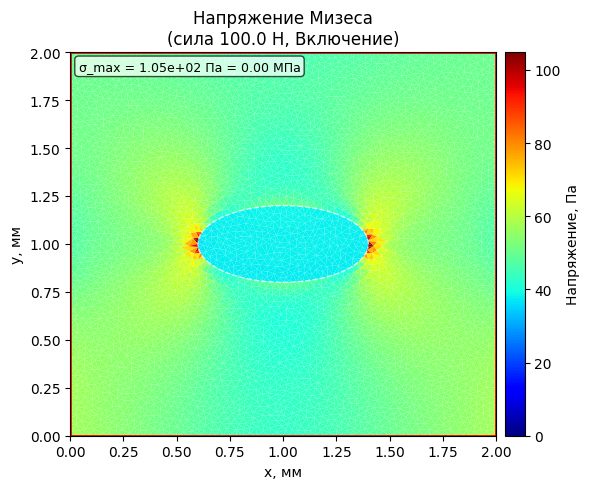

In [2]:
# ============================================================
# Задача Кирша и Эшелби:
# пластина с эллиптическим дефектом
# ============================================================
# D. Klyukin

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
from meshpy.triangle import MeshInfo, build as build_mesh
from ipywidgets import Button, VBox, FloatSlider, Dropdown
from IPython.display import display, clear_output

REAL_SIZE_M = 0.002
SCALE_MM = REAL_SIZE_M * 1000

E_matrix = 200e9
nu_matrix = 0.30
D_matrix = E_matrix / (1 - nu_matrix**2) * np.array([
    [1, nu_matrix, 0],
    [nu_matrix, 1, 0],
    [0, 0, (1 - nu_matrix)/2]
])


# Можно добовлять свои материалы

MATERIALS = {
    "Сталь (E=200 ГПа, ν=0.30)": {"E": 200e9, "nu": 0.30},
    "Пушечная бронза (E=100 ГПа, ν=0.34)": {"E": 100e9, "nu": 0.34},
    "Алюминий (E=70 ГПа, ν=0.33)": {"E": 70e9, "nu": 0.33},
    "Титан (E=110 ГПа, ν=0.34)": {"E": 110e9, "nu": 0.34},
    "Никель (E=200 ГПа, ν=0.31)": {"E": 200e9, "nu": 0.31},
    "АБС-пластик (E=2.2 ГПа, ν=0.38)": {"E": 2.2e9, "nu": 0.38},
    "PETG (E=2.1 ГПа, ν=0.42)": {"E": 2.1e9, "nu": 0.42},
}

DEFECT_TYPES = {
    "Отверстие": "hole",
    "Включение": "inclusion"
}

FIELD_TYPES = [
    "Напряжение Мизеса",
    "Эквивалентная деформация",
    "Деформация εxx",
    "Деформация εyy",
    "Сдвиг γxy",
]

sigma_vm = None
eps_eq = None
eps_xx = None
eps_yy = None
eps_xy = None
eps_1 = None
eps_2 = None
gamma_max = None
nodes = None
tris = None


def ellipse_points(cx, cy, a, b, angle_deg, n_pts=80):
    theta = np.linspace(0, 2*np.pi, n_pts, endpoint=False)
    c = np.cos(np.radians(angle_deg))
    s = np.sin(np.radians(angle_deg))
    x = cx + a * np.cos(theta) * c - b * np.sin(theta) * s
    y = cy + a * np.cos(theta) * s + b * np.sin(theta) * c
    return np.column_stack([x, y])

def solve_and_plot(cx, cy, a, b, angle_deg, real_force, max_area,
                   material_choice, defect_type_choice, field_choice):

    global sigma_vm, eps_eq, eps_xx, eps_yy, eps_xy, eps_1, eps_2, gamma_max
    global nodes, tris

    defect_type = DEFECT_TYPES[defect_type_choice]

    if defect_type == "inclusion":
        m = MATERIALS[material_choice]
        D_inc = m["E"] / (1 - m["nu"]**2) * np.array([
            [1, m["nu"], 0],
            [m["nu"], 1, 0],
            [0, 0, (1 - m["nu"])/2]
        ])
    else:
        D_inc = None

    # сила делится на две грани
    f_side = (real_force / 2) / REAL_SIZE_M

    # геометрия
    outer = np.array([[0,0], [1,0], [1,1], [0,1]])
    inc = ellipse_points(cx, cy, a, b, angle_deg)
    all_pts = np.vstack([outer, inc])
    n_inc = len(inc)

    edges = [(i, (i+1) % 4) for i in range(4)]
    edges += [(4+i, 4+(i+1) % n_inc) for i in range(n_inc)]

    mesh_info = MeshInfo()
    mesh_info.set_points(all_pts)
    mesh_info.set_facets(edges)
    if defect_type == "hole":
        mesh_info.set_holes([(cx, cy)])

    mesh = build_mesh(mesh_info, max_volume=max_area)
    nodes = np.array(mesh.points)
    tris = np.array(mesh.elements)
    N = nodes.shape[0]
    M = tris.shape[0]

    # элементы внутри включения
    if defect_type == "inclusion":
        centers = np.array([np.mean(nodes[tri, :], axis=0) for tri in tris])
        c = np.cos(np.radians(angle_deg))
        s = np.sin(np.radians(angle_deg))
        dx = centers[:, 0] - cx
        dy = centers[:, 1] - cy
        xr = dx * c + dy * s
        yr = -dx * s + dy * c
        inside = (xr**2 / a**2 + yr**2 / b**2) <= 1.0
    else:
        inside = np.zeros(M, dtype=bool)

    # -----------------Сборка матрицы----------------------------
    I = []; J = []; V = []
    for t in range(M):
        nd = tris[t]
        xy = nodes[nd, :]
        x1, y1 = xy[0]; x2, y2 = xy[1]; x3, y3 = xy[2]
        area2 = (x2-x1)*(y3-y1) - (x3-x1)*(y2-y1)
        area = abs(area2) / 2.0
        if area < 1e-12:
            continue

        b1, b2, b3 = y2-y3, y3-y1, y1-y2
        c1, c2, c3 = x3-x2, x1-x3, x2-x1

        B = np.array([
            [b1, 0, b2, 0, b3, 0],
            [0, c1, 0, c2, 0, c3],
            [c1, b1, c2, b2, c3, b3]
        ]) / (2 * area)

        D = D_inc if (defect_type == "inclusion" and inside[t]) else D_matrix
        K_loc = B.T @ D @ B * area

        dof = []
        for node in nd:
            dof += [2*node, 2*node + 1]

        for i in range(6):
            for j in range(6):
                I.append(dof[i])
                J.append(dof[j])
                V.append(K_loc[i, j])

    K = coo_matrix((V, (I, J)), shape=(2*N, 2*N)).tocsc()

    # закрепления: левая грань по X, нижняя по Y
    tol = 1e-9

    bottom = np.where(nodes[:,1] < tol)[0]
    for node in bottom:
        d = 2*node + 1
        K[d, :] = 0
        K[:, d] = 0
        K[d, d] = 1

    # Одна точка, чтобы убрать вращение тела как целого
    n_fix = np.argmin(nodes[:,0]**2 + nodes[:,1]**2)
    d = 2*n_fix
    K[d, :] = 0
    K[:, d] = 0
    K[d, d] = 1

    # ---------------------------Нагрузка: верх и низ, кроме углов----------------------

    top = np.where(nodes[:,1] > 1-tol)[0]
    top_sorted = top[np.argsort(nodes[top, 0])]
    xs = nodes[top_sorted, 0]

    L = np.zeros(len(xs))
    if len(xs) > 1:
        L[0]  = (xs[1]  - xs[0])   / 2
        L[-1] = (xs[-1] - xs[-2])  / 2
        L[1:-1] = (xs[2:] - xs[:-2]) / 2

    F = np.zeros(2*N)
    # Сила = real_force/2 в тех же единицах, что и раньше
    F[2*top_sorted + 1] += (real_force / 2) * L / L.sum()

    # Обнуляем силу в закреплённых DOF (реакции)
    for node in bottom:
        F[2*node + 1] = 0
    F[2*n_fix] = 0

    U = spsolve(K, F)
    u = U[0::2]
    v = U[1::2]

    # поля
    sigma_vm = np.zeros(M)
    eps_eq = np.zeros(M)
    eps_xx = np.zeros(M)
    eps_yy = np.zeros(M)
    eps_xy = np.zeros(M)
    eps_1 = np.zeros(M)
    eps_2 = np.zeros(M)
    gamma_max = np.zeros(M)

    for t in range(M):
        nd = tris[t]
        xy = nodes[nd, :]
        x1, y1 = xy[0]; x2, y2 = xy[1]; x3, y3 = xy[2]
        area2 = abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
        area = area2 / 2.0
        if area < 1e-12:
            continue

        b1, b2, b3 = y2-y3, y3-y1, y1-y2
        c1, c2, c3 = x3-x2, x1-x3, x2-x1

        B = np.array([
            [b1, 0, b2, 0, b3, 0],
            [0, c1, 0, c2, 0, c3],
            [c1, b1, c2, b2, c3, b3]
        ]) / (2 * area)

        ue = np.array([u[nd[0]], v[nd[0]],
                       u[nd[1]], v[nd[1]],
                       u[nd[2]], v[nd[2]]])

        e = B @ ue
        eps_xx[t] = e[0]
        eps_yy[t] = e[1]
        eps_xy[t] = e[2]

        eps_eq[t] = (2/np.sqrt(3)) * np.sqrt(
            e[0]**2 + e[1]**2 + e[0]*e[1] + e[2]**2/4
        )

        avg = (e[0] + e[1]) / 2
        dif = (e[0] - e[1]) / 2
        R = np.sqrt(dif**2 + (e[2]/2)**2)
        eps_1[t] = avg + R
        eps_2[t] = avg - R
        gamma_max[t] = eps_1[t] - eps_2[t]

        D = D_inc if (defect_type == "inclusion" and inside[t]) else D_matrix
        s = D @ e
        sigma_vm[t] = np.sqrt(s[0]**2 + s[1]**2 - s[0]*s[1] + 3*s[2]**2)

    # выбор поля
    if field_choice == "Напряжение Мизеса":
        field = sigma_vm; fmax = field.max() if M > 0 else 0
        cl = 'Напряжение, Па'
        info = f'σ_max = {fmax:.2e} Па = {fmax/1e6:.2f} МПа'
    elif field_choice == "Эквивалентная деформация":
        field = eps_eq; fmax = field.max() if M > 0 else 0
        cl = 'ε_eq'
        info = f'ε_eq_max = {fmax:.3e}'
    elif field_choice == "Деформация εxx":
        field = eps_xx; fmax = np.abs(field).max() if M > 0 else 0
        cl = 'εxx'
        info = f'εxx_max = {fmax:.3e}'
    elif field_choice == "Деформация εyy":
        field = eps_yy; fmax = np.abs(field).max() if M > 0 else 0
        cl = 'εyy'
        info = f'εyy_max = {fmax:.3e}'
    else:
        field = eps_xy; fmax = np.abs(field).max() if M > 0 else 0
        cl = 'γxy'
        info = f'γxy_max = {fmax:.3e}'

    # --------------------Картинка---------------------------

    nm = nodes * SCALE_MM
    im = inc * SCALE_MM
    sm_mm = REAL_SIZE_M * 1000

    fig, ax = plt.subplots(figsize=(6, 5))
    for t in range(M):
        tn = nm[tris[t], :]
        cv = field[t] / fmax if fmax > 0 else 0
        ax.fill(tn[:,0], tn[:,1], facecolor=plt.cm.jet(cv), edgecolor='none')

    ax.plot([0, sm_mm, sm_mm, 0, 0], [0, 0, sm_mm, sm_mm, 0], 'r-', lw=2)
    ax.plot(im[:,0], im[:,1], 'w--', lw=1, alpha=0.7)
    ax.set_xlim(0, sm_mm); ax.set_ylim(0, sm_mm)
    ax.set_xlabel('x, мм'); ax.set_ylabel('y, мм')
    ax.set_title(f'{field_choice}\n(сила {real_force} Н, {defect_type_choice})')

    smp = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, fmax))
    cbar = plt.colorbar(smp, ax=ax, fraction=0.05, pad=0.02)
    cbar.set_label(cl)
    ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=9,
            va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    plt.tight_layout()
    plt.show()

    print(f"Узлов: {N}, элементов: {M}")
    print(info)


style = {'description_width': 'initial'}
w_cx = FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, description='Центр x', style=style)
w_cy = FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5, description='Центр y', style=style)
w_a = FloatSlider(min=0.01, max=0.4, step=0.01, value=0.2, description='Полуось a', style=style)
w_b = FloatSlider(min=0.01, max=0.4, step=0.01, value=0.1, description='Полуось b', style=style)
w_angle = FloatSlider(min=0, max=180, step=5, value=0, description='Угол', style=style)
w_force = FloatSlider(min=10, max=500, step=10, value=100, description='Сила, Н', style=style)
w_area = FloatSlider(min=0.0001, max=0.005, step=0.0001, value=0.002,
                     description='Max area', style=style, readout_format='.4f')
w_material = Dropdown(options=list(MATERIALS.keys()),
                      value="Пушечная бронза (E=100 ГПа, ν=0.34)",
                      description='Материал', style=style)
w_defect = Dropdown(options=list(DEFECT_TYPES.keys()), value="Включение",
                    description='Дефект', style=style)
w_field = Dropdown(options=FIELD_TYPES, value="Напряжение Мизеса",
                   description='Показывать', style=style)

button = Button(description="Применить", layout={'width': '120px'})


def on_click(b):
    clear_output(wait=True)
    solve_and_plot(w_cx.value, w_cy.value, w_a.value, w_b.value, w_angle.value,
                   w_force.value, w_area.value, w_material.value,
                   w_defect.value, w_field.value)
    display(controls)


button.on_click(on_click)

controls = VBox([w_cx, w_cy, w_a, w_b, w_angle, w_force, w_area,
                 w_material, w_defect, w_field, button])
display(controls)
on_click(None)